# NB03 — Preprocessing
**Project:** NAFLD Stage-Specific Biomarker Discovery (Single-Dataset Pipeline)  
**Dataset:** GSE135251 — Govaere et al., *Science Translational Medicine*, 2020

---

**Purpose:** Normalize the raw RNA-seq count matrix, remove low-variance genes,
detect outlier samples, and produce a clean expression matrix ready for
feature selection and modeling.

**Preprocessing Pipeline:**
1. Load raw counts + labeled metadata (from NB01 & NB02)
2. Normalize: log₂(CPM + 1) — standard for RNA-seq count data
3. Low-variance gene filtering: remove bottom 20% by IQR
4. Outlier sample detection: flag samples > 3 SD from PCA centroid
5. Save preprocessed expression matrix

**No batch correction needed** — single dataset, single platform, single study.


## 1. Install Dependencies

In [1]:
# ── DEPENDENCIES ──────────────────────────────────────────────────
import subprocess, sys

packages = [
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "scikit-learn",
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "--quiet"])

print("All dependencies installed.")


All dependencies installed.


## 2. Configuration

In [2]:
# ── CONFIGURATION ─────────────────────────────────────────────────
import pathlib

RANDOM_SEED = 42
REDOWNLOAD  = False

PROJECT_ROOT = pathlib.Path("..").resolve()
DATA_RAW     = PROJECT_ROOT / "data" / "raw"
DATA_META    = PROJECT_ROOT / "data" / "metadata"
DATA_PROC    = PROJECT_ROOT / "data" / "processed"
RESULTS_FIG  = PROJECT_ROOT / "results" / "figures"

DATA_PROC.mkdir(parents=True, exist_ok=True)
RESULTS_FIG.mkdir(parents=True, exist_ok=True)

# Preprocessing parameters
IQR_PERCENTILE_CUTOFF = 0.20   # Remove bottom 20% of genes by IQR
OUTLIER_SD_THRESHOLD  = 3.0    # Flag samples > 3 SD from PCA centroid

# Class names for plots
CLASS_NAMES  = {0: "Healthy", 1: "Steatosis", 2: "NASH", 3: "Adv. Fibrosis"}
CLASS_COLORS = {0: "#2ecc71", 1: "#3498db", 2: "#e67e22", 3: "#e74c3c"}
DPI = 300

print(f"Project root: {PROJECT_ROOT}")
print(f"IQR cutoff  : bottom {IQR_PERCENTILE_CUTOFF:.0%}")
print(f"Outlier threshold: {OUTLIER_SD_THRESHOLD} SD")


Project root: D:\NAFLD-Biomarker-Discovery-V2\nafld-single-dataset
IQR cutoff  : bottom 20%
Outlier threshold: 3.0 SD


## 3. Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import warnings

np.random.seed(RANDOM_SEED)
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.dpi": DPI,
    "savefig.dpi": DPI,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

print("All imports loaded.")


All imports loaded.


## 4. Load Data

In [4]:
if REDOWNLOAD:
    raise NotImplementedError("Run NB01 first. Set REDOWNLOAD=False.")

# Load raw expression matrix (genes × samples)
expr_path = DATA_RAW / "expression_matrix_raw.csv"
assert expr_path.exists(), f"Missing: {expr_path}. Run NB01 first."
expression = pd.read_csv(expr_path, index_col=0)
print(f"Raw expression matrix: {expression.shape} (genes × samples)")

# Load labeled metadata
meta_path = DATA_META / "labeled_metadata.csv"
assert meta_path.exists(), f"Missing: {meta_path}. Run NB02 first."
metadata = pd.read_csv(meta_path)
print(f"Metadata: {metadata.shape}")

# Align samples
common_samples = sorted(set(expression.columns) & set(metadata["sample_id"]))
expression = expression[common_samples]
metadata = metadata[metadata["sample_id"].isin(common_samples)].copy()
metadata = metadata.set_index("sample_id").loc[common_samples].reset_index()

print(f"Aligned samples: {len(common_samples)}")
print(f"Expression: {expression.shape}")
print(f"Metadata: {metadata.shape}")


Raw expression matrix: (42584, 216) (genes × samples)
Metadata: (216, 8)
Aligned samples: 216
Expression: (42584, 216)
Metadata: (216, 8)


## 5. Normalization: log₂(CPM + 1)

Since GSE135251 provides **raw RNA-seq counts**, we apply the standard
log₂(CPM + 1) normalization:

1. **CPM** (Counts Per Million): normalizes for library size differences between samples
2. **log₂(x + 1)**: stabilizes variance and makes the distribution more symmetric

This is the standard normalization for RNA-seq data when using general ML methods
(as opposed to DESeq2/edgeR which have their own normalization).


In [5]:
# Compute library sizes (total counts per sample)
library_sizes = expression.sum(axis=0)
print(f"Library size range: {library_sizes.min():,.0f} – {library_sizes.max():,.0f}")
print(f"Library size mean:  {library_sizes.mean():,.0f}")
print(f"Library size CV:    {library_sizes.std() / library_sizes.mean():.3f}")

# CPM normalization
cpm = expression.div(library_sizes, axis=1) * 1e6

# log2(CPM + 1)
expr_norm = np.log2(cpm + 1)

print(f"\nNormalized expression matrix: {expr_norm.shape}")
print(f"Value range: {expr_norm.values.min():.2f} – {expr_norm.values.max():.2f}")
print(f"Mean expression: {expr_norm.values.mean():.2f}")


Library size range: 14,648,105 – 37,746,268
Library size mean:  24,529,702
Library size CV:    0.160

Normalized expression matrix: (42584, 216)
Value range: 0.00 – 17.85
Mean expression: 1.21


### 5.1 Expression Distribution Before/After Normalization

C:\Users\karim\AppData\Local\Temp\ipykernel_8708\1871787634.py:22: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\karim\AppData\Local\Temp\ipykernel_8708\1871787634.py:22: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\karim\AppData\Local\Temp\ipykernel_8708\1871787634.py:22: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\karim\AppData\Local\Temp\ipykernel_8708\1871787634.py:23: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig(RESULTS_FIG / "fig_preproc_normalization.png", bbox_inches="tight")
C:\Users\karim\AppData\Local\Temp\ipykernel_8708\1871787634.py:23: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.savefig(RESULTS_FIG / "fig_preproc_normalization.png", bbox_inches="tight")
C:\Users\karim\AppData\Local\Temp\ipykernel_8708\1871787634.py:23: UserWarni

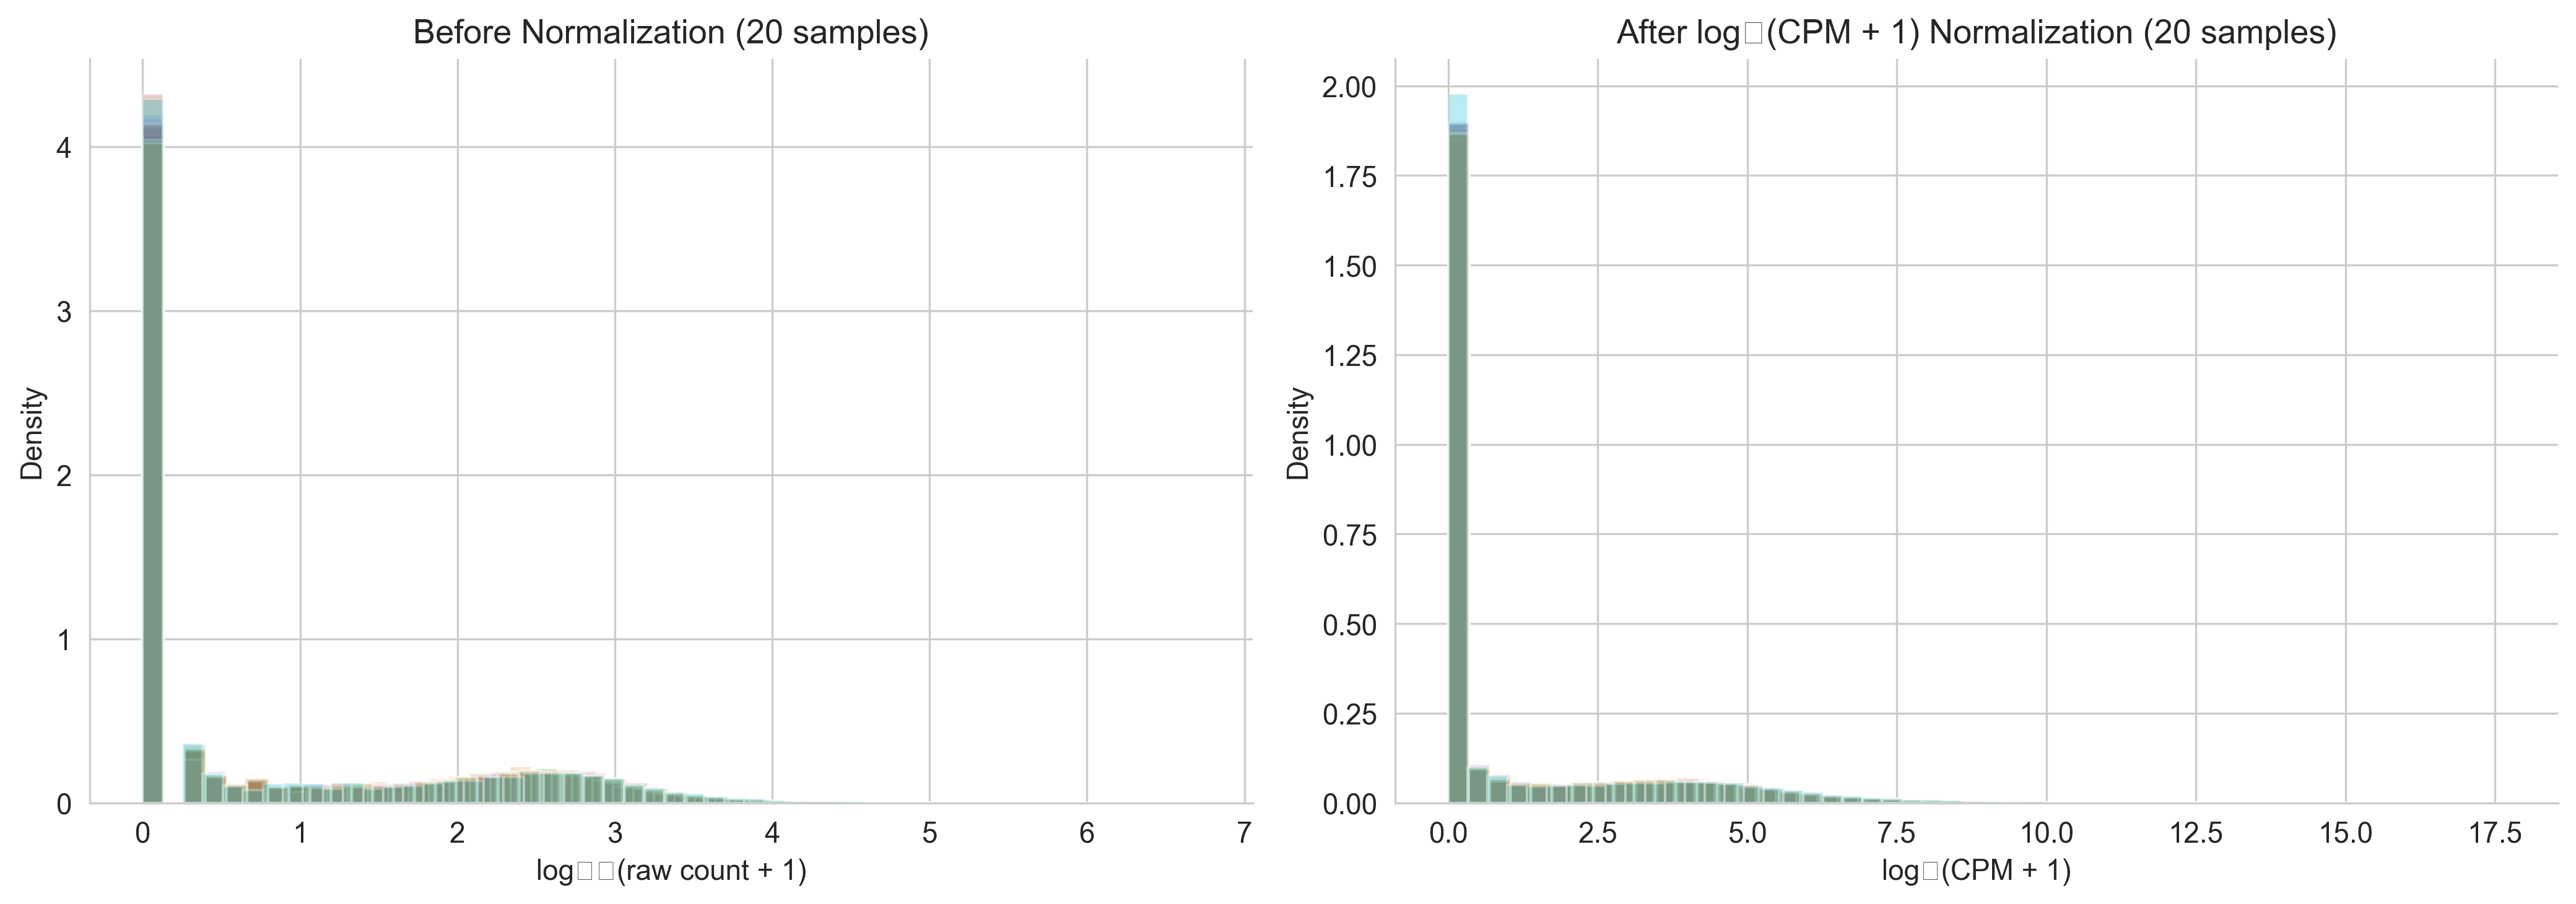

Saved: D:\NAFLD-Biomarker-Discovery-V2\nafld-single-dataset\results\figures\fig_preproc_normalization.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before: raw counts (log10 scale for visibility)
sample_subset = expression.columns[:20]
for s in sample_subset:
    vals = np.log10(expression[s].values + 1)
    axes[0].hist(vals, bins=50, alpha=0.3, density=True)
axes[0].set_xlabel("log₁₀(raw count + 1)")
axes[0].set_ylabel("Density")
axes[0].set_title("Before Normalization (20 samples)")

# After: log2(CPM+1)
for s in sample_subset:
    axes[1].hist(expr_norm[s].values, bins=50, alpha=0.3, density=True)
axes[1].set_xlabel("log₂(CPM + 1)")
axes[1].set_ylabel("Density")
axes[1].set_title("After log₂(CPM + 1) Normalization (20 samples)")

for ax in axes:
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(RESULTS_FIG / "fig_preproc_normalization.png", bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_FIG / 'fig_preproc_normalization.png'}")


### 5.2 Library Size Distribution

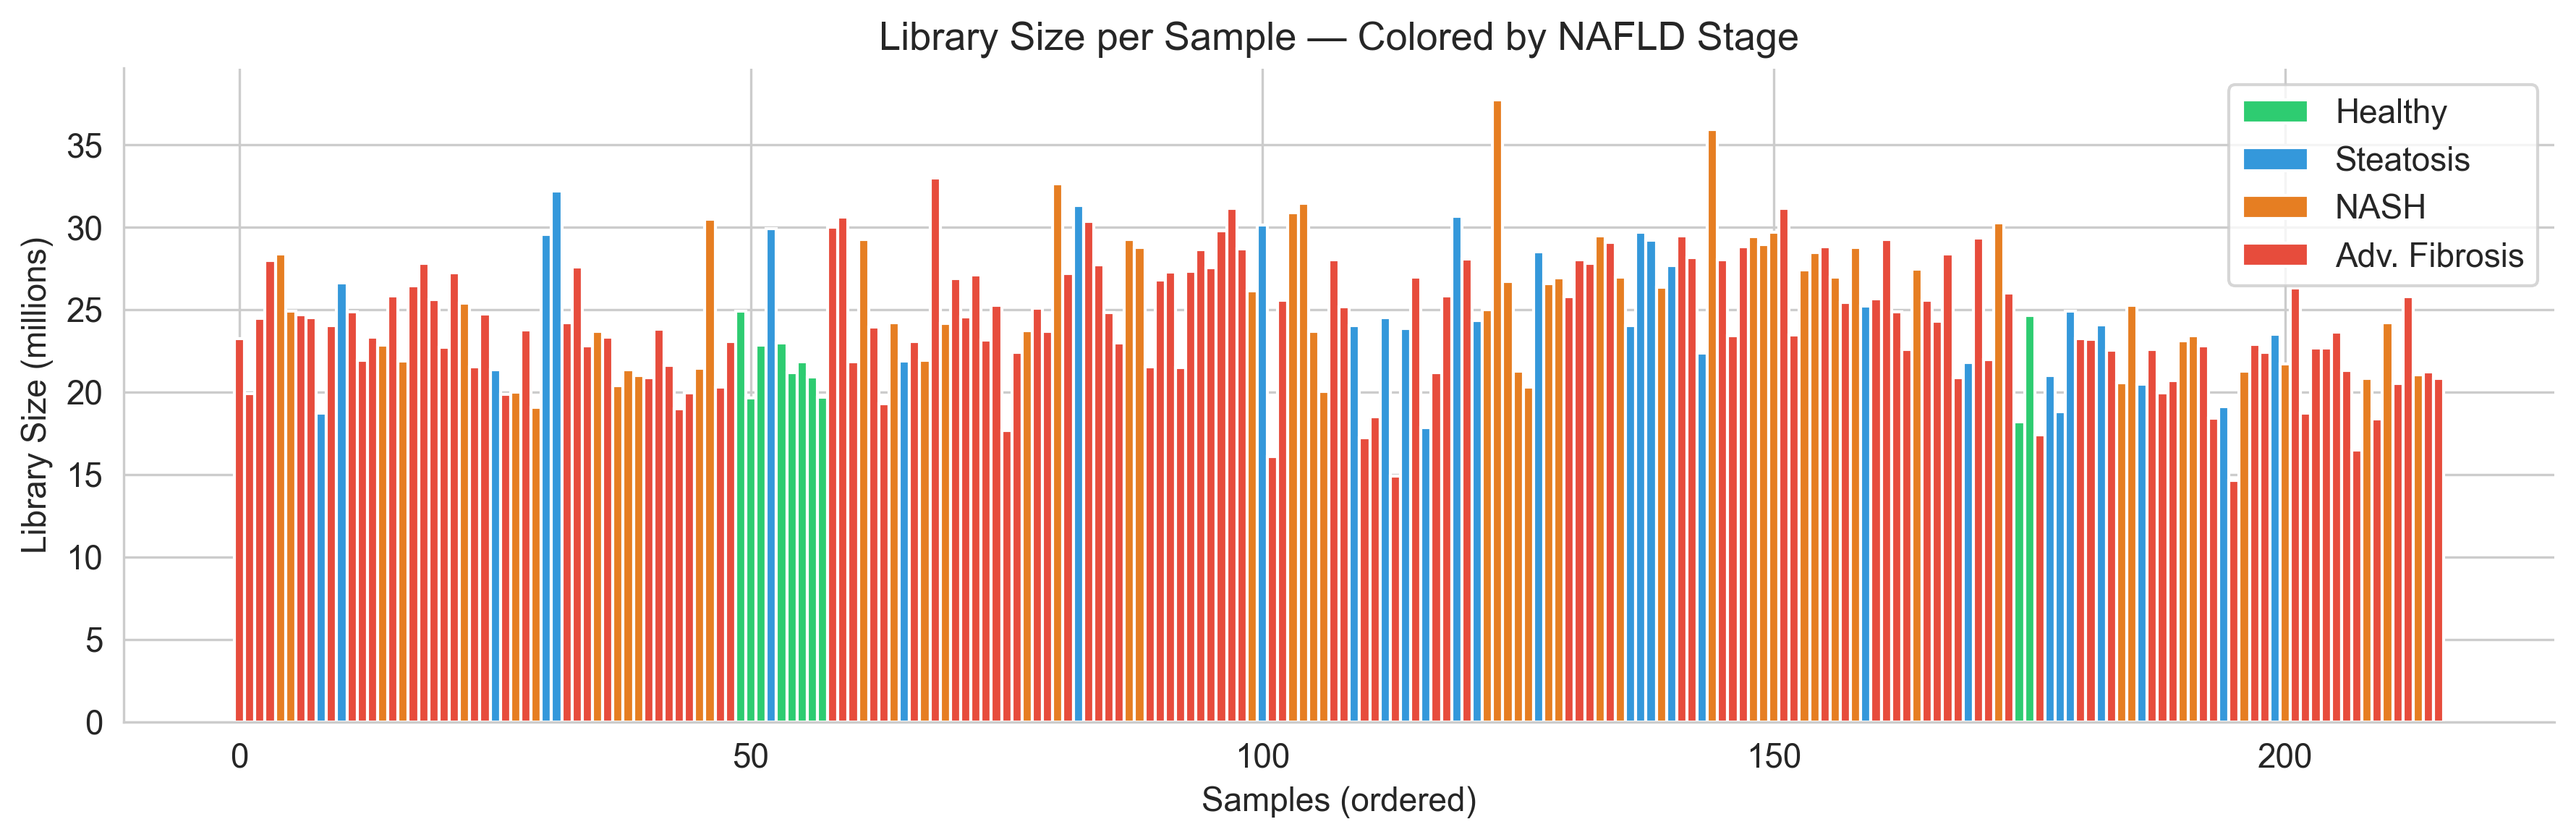

Saved: D:\NAFLD-Biomarker-Discovery-V2\nafld-single-dataset\results\figures\fig_preproc_library_sizes.png


In [7]:
labels = metadata.set_index("sample_id").loc[expression.columns, "nafld_stage"]
colors = [CLASS_COLORS[int(l)] for l in labels.values]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(library_sizes)), library_sizes.values / 1e6, color=colors, width=1.0)
ax.set_xlabel("Samples (ordered)")
ax.set_ylabel("Library Size (millions)")
ax.set_title("Library Size per Sample — Colored by NAFLD Stage")

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=CLASS_COLORS[i], label=CLASS_NAMES[i]) for i in sorted(CLASS_NAMES)]
ax.legend(handles=legend_elements, loc="upper right")
sns.despine()
plt.tight_layout()
plt.savefig(RESULTS_FIG / "fig_preproc_library_sizes.png", bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_FIG / 'fig_preproc_library_sizes.png'}")


## 6. Low-Variance Gene Filtering

Remove genes in the bottom 20% by interquartile range (IQR).  
Low-variance genes carry minimal discriminative signal and inflate
dimensionality, reducing model performance.


In [8]:
# Data Leakage Fix: We defer variance filtering to NB04 after train_test_split.
# For now, we keep all normalized genes.
expr_filtered = expr_norm.copy()

print(f"Genes in preprocessed matrix: {expr_filtered.shape[0]:,}")

Genes in preprocessed matrix: 42,584


### 6.1 IQR Distribution

In [9]:
pass # Skipped due to deferred variance filtering

## 7. Outlier Sample Detection

Flag samples whose PCA projection is > 3 standard deviations from the centroid.  
These samples are **flagged but not removed** — removal requires documented justification.


In [10]:
# PCA on filtered expression
pca = PCA(n_components=2, random_state=RANDOM_SEED)
pca_coords = pca.fit_transform(expr_filtered.T)  # (samples, 2)

# Compute distances from centroid
centroid = pca_coords.mean(axis=0)
distances = np.sqrt(((pca_coords - centroid) ** 2).sum(axis=1))
mean_dist = distances.mean()
std_dist  = distances.std()
threshold = mean_dist + OUTLIER_SD_THRESHOLD * std_dist

outlier_mask = distances > threshold
outlier_samples = [expression.columns[i] for i, is_out in enumerate(outlier_mask) if is_out]

print(f"PCA variance explained: PC1={pca.explained_variance_ratio_[0]:.1%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.1%}")
print(f"Distance: mean={mean_dist:.2f}, std={std_dist:.2f}, threshold={threshold:.2f}")
print(f"Outlier samples flagged: {len(outlier_samples)}")
for s in outlier_samples:
    idx = list(expression.columns).index(s)
    stage = metadata[metadata["sample_id"] == s]["nafld_stage"].values[0]
    print(f"  [!] {s} — Class {stage} ({CLASS_NAMES[stage]}), "
          f"distance={distances[idx]:.2f}")


PCA variance explained: PC1=26.8%, PC2=11.2%
Distance: mean=33.63, std=18.36, threshold=88.71
Outlier samples flagged: 4
  [!] GSM3998232 — Class 1 (Steatosis), distance=94.93
  [!] GSM3998259 — Class 3 (Adv. Fibrosis), distance=99.49
  [!] GSM3998260 — Class 3 (Adv. Fibrosis), distance=88.91
  [!] GSM3998280 — Class 3 (Adv. Fibrosis), distance=103.17


### 7.1 PCA with Outliers Highlighted

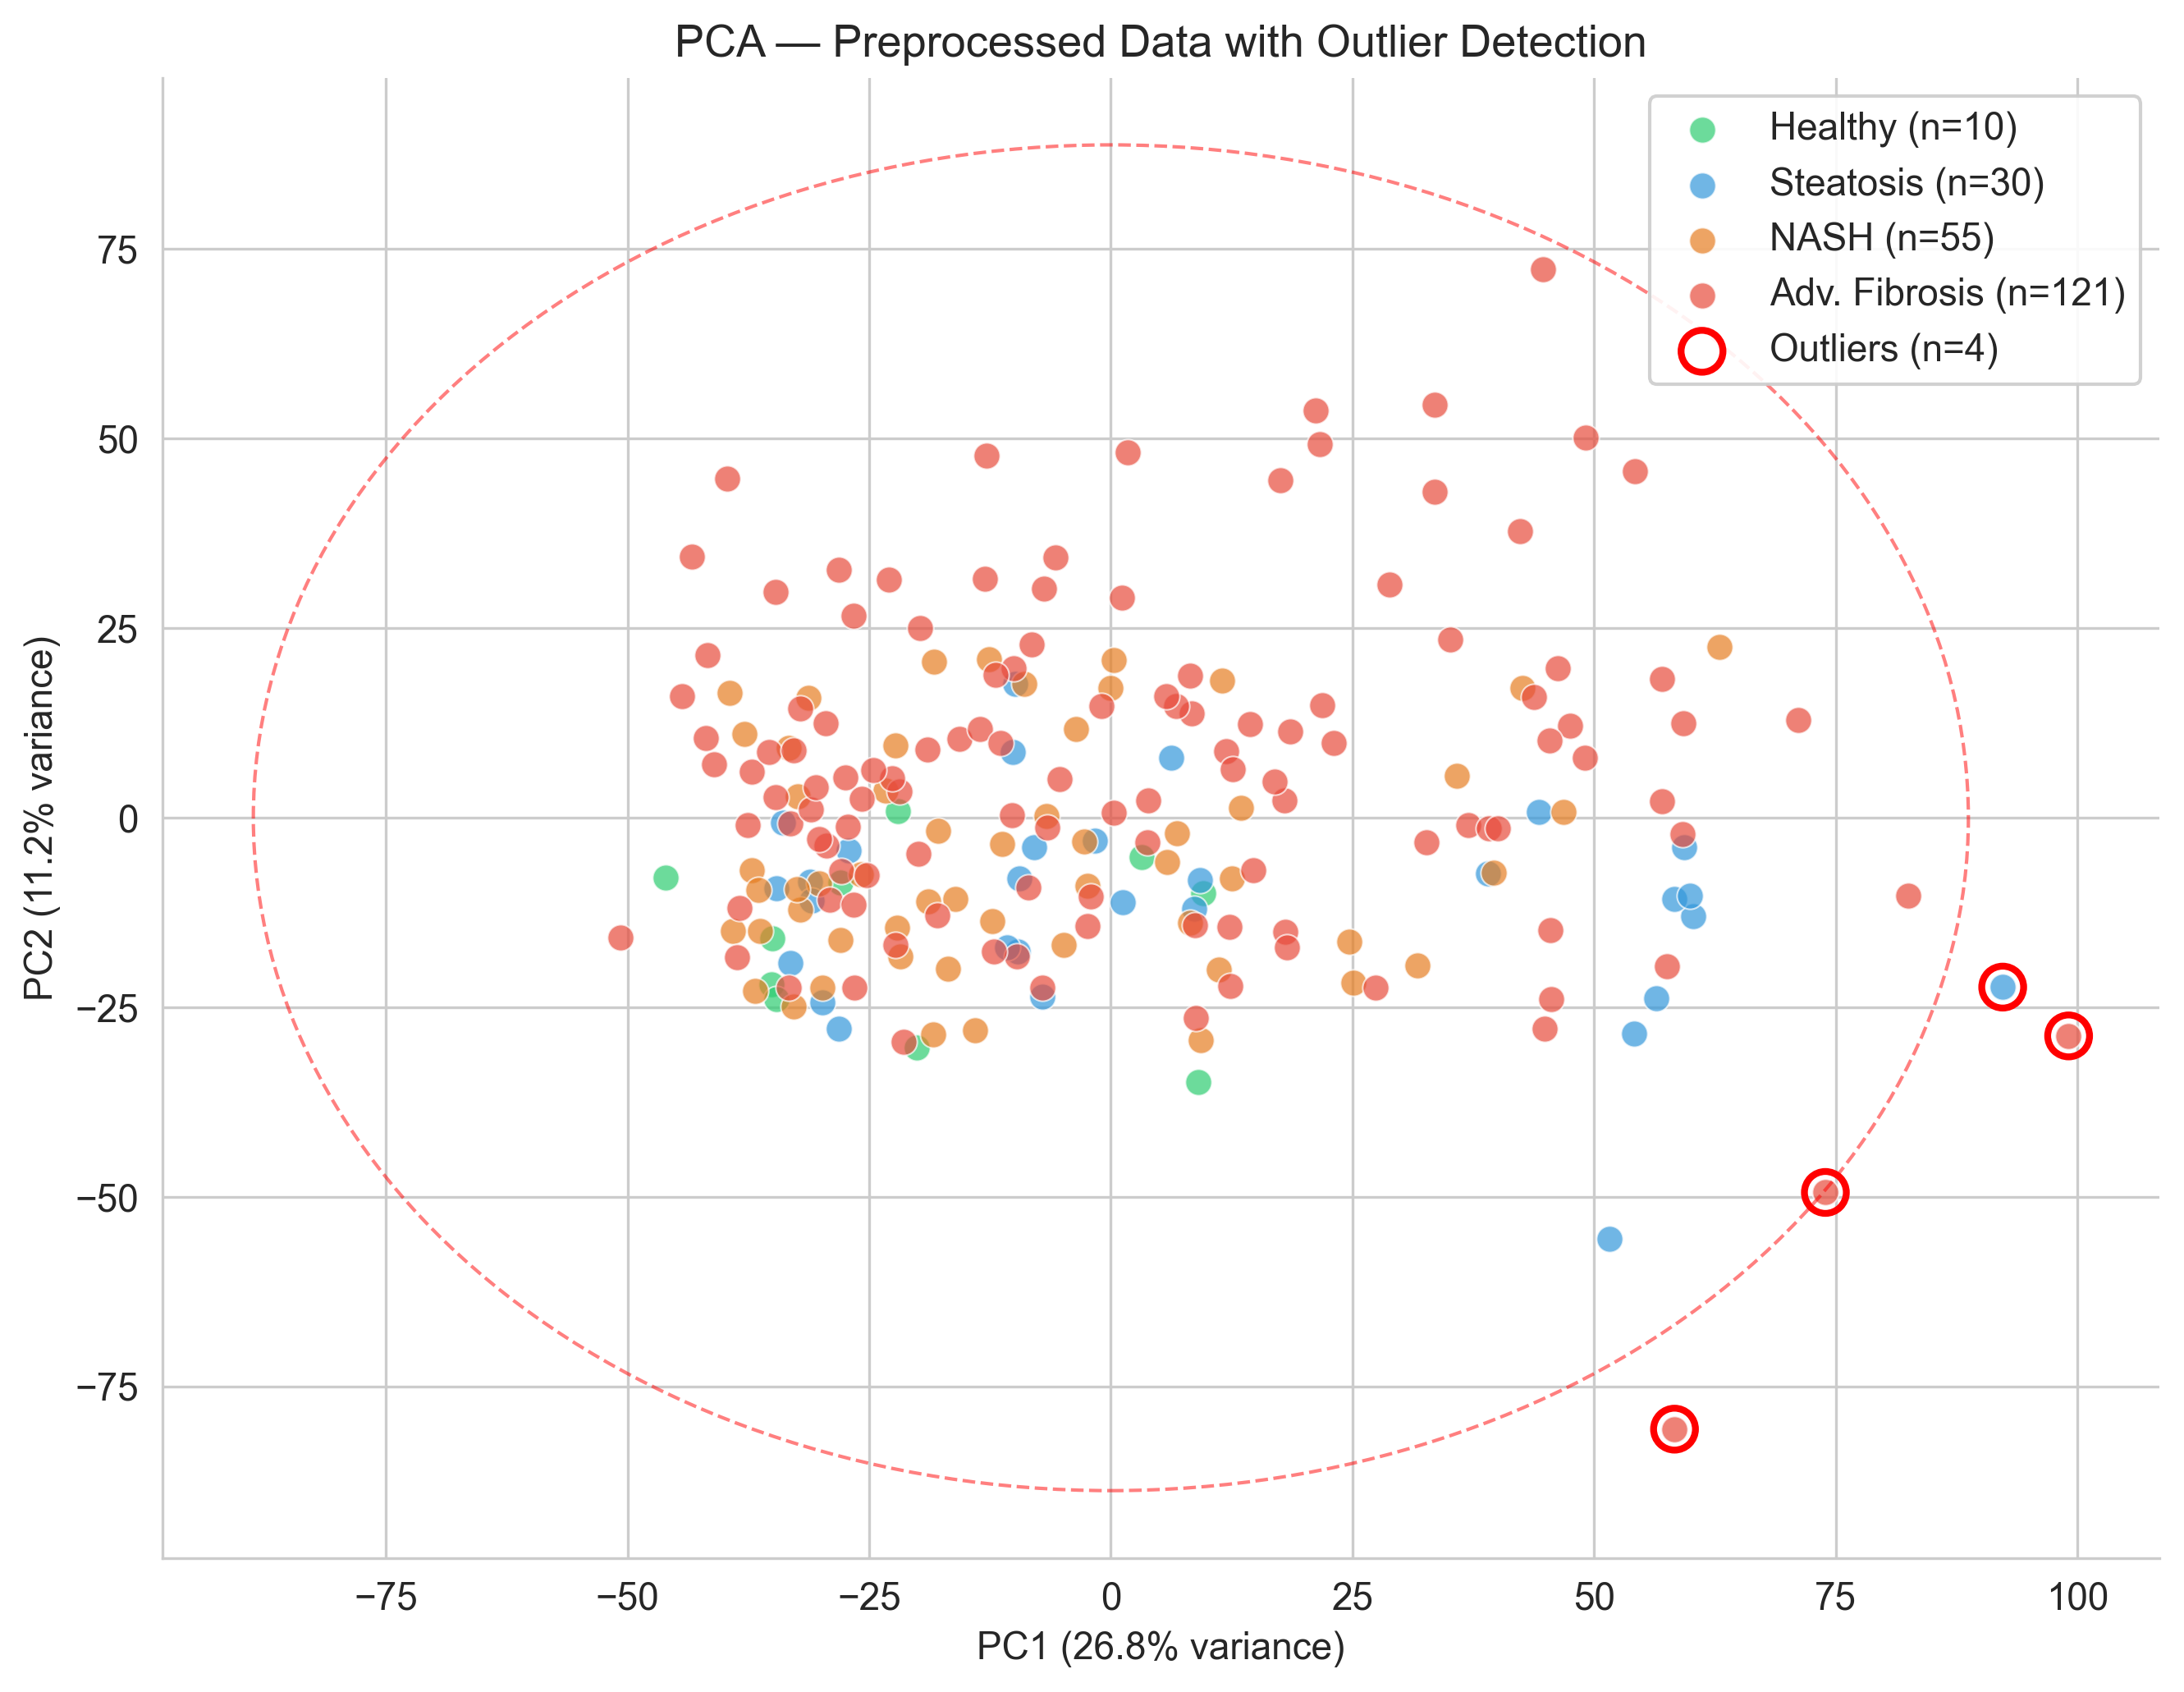

Saved: D:\NAFLD-Biomarker-Discovery-V2\nafld-single-dataset\results\figures\Supp_Fig_1_pca_outliers.png


In [11]:
meta_aligned = metadata.set_index("sample_id").loc[expression.columns]

fig, ax = plt.subplots(figsize=(9, 7))

for cls_id in sorted(CLASS_NAMES.keys()):
    mask = meta_aligned["nafld_stage"].values == cls_id
    ax.scatter(
        pca_coords[mask, 0], pca_coords[mask, 1],
        c=CLASS_COLORS[cls_id],
        label=f"{CLASS_NAMES[cls_id]} (n={mask.sum()})",
        alpha=0.7, edgecolors="white", linewidths=0.5, s=60
    )

# Highlight outliers
if len(outlier_samples) > 0:
    ax.scatter(
        pca_coords[outlier_mask, 0], pca_coords[outlier_mask, 1],
        facecolors="none", edgecolors="red", linewidths=2, s=150,
        label=f"Outliers (n={len(outlier_samples)})", zorder=5
    )
    # Add threshold circle
    circle = plt.Circle(centroid, threshold, fill=False, color="red",
                        linestyle="--", linewidth=1, alpha=0.5)
    ax.add_patch(circle)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("PCA — Preprocessed Data with Outlier Detection")
ax.legend(loc="best", framealpha=0.9)
sns.despine()
plt.tight_layout()
plt.savefig(RESULTS_FIG / "Supp_Fig_1_pca_outliers.png", bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_FIG / 'Supp_Fig_1_pca_outliers.png'}")


### 7.2 Outlier Decision

Per AGENT_RULES.md: outlier samples are **reported but not automatically removed**.  
If no outliers are flagged, no action is needed.  
If outliers are present, the researcher should review them before deciding on removal.


In [12]:
if len(outlier_samples) == 0:
    print("[OK] No outlier samples detected. Proceeding with all samples.")
    expr_final = expr_filtered.copy()
else:
    print(f"[!] {len(outlier_samples)} outlier(s) flagged.")
    print("  Decision: KEEP all samples (outliers documented but not removed).")
    print("  Rationale: Small dataset — removing samples risks losing statistical power.")
    print("  The researcher should review these samples before final publication.")
    expr_final = expr_filtered.copy()

print(f"\nFinal preprocessed matrix: {expr_final.shape}")


[!] 4 outlier(s) flagged.
  Decision: KEEP all samples (outliers documented but not removed).
  Rationale: Small dataset — removing samples risks losing statistical power.
  The researcher should review these samples before final publication.

Final preprocessed matrix: (42584, 216)


## 8. Save Preprocessed Expression Matrix

In [13]:
# Save preprocessed expression (genes × samples)
preproc_path = DATA_PROC / "expression_preprocessed.csv"
expr_final.to_csv(preproc_path)
print(f"Saved: {preproc_path}")
print(f"  Shape: {expr_final.shape} (genes × samples)")

# Save outlier report
outlier_report = pd.DataFrame({
    "sample_id": expression.columns,
    "pca_distance": distances,
    "is_outlier": outlier_mask,
    "nafld_stage": meta_aligned["nafld_stage"].values,
})
outlier_path = DATA_PROC / "outlier_report.csv"
outlier_report.to_csv(outlier_path, index=False)
print(f"Saved: {outlier_path}")


Saved: D:\NAFLD-Biomarker-Discovery-V2\nafld-single-dataset\data\processed\expression_preprocessed.csv
  Shape: (42584, 216) (genes × samples)
Saved: D:\NAFLD-Biomarker-Discovery-V2\nafld-single-dataset\data\processed\outlier_report.csv


## 9. Output Manifest

In [14]:
output_files = [
    DATA_PROC / "expression_preprocessed.csv",
    DATA_PROC / "outlier_report.csv",
    RESULTS_FIG / "fig_preproc_normalization.png",
    RESULTS_FIG / "fig_preproc_library_sizes.png",
    RESULTS_FIG / "fig_preproc_iqr_distribution.png",
    RESULTS_FIG / "Supp_Fig_1_pca_outliers.png",
]

print("=" * 60)
print("OUTPUT MANIFEST")
print("=" * 60)
for fp in output_files:
    if fp.exists():
        size_mb = fp.stat().st_size / 1e6
        print(f"  [OK] {fp.name:45s} {size_mb:8.2f} MB")
    else:
        print(f"  [FAIL] {fp.name:45s} MISSING")
print("=" * 60)


OUTPUT MANIFEST
  [OK] expression_preprocessed.csv                      99.51 MB
  [OK] outlier_report.csv                                0.01 MB
  [OK] fig_preproc_normalization.png                     0.15 MB
  [OK] fig_preproc_library_sizes.png                     0.11 MB
  [FAIL] fig_preproc_iqr_distribution.png              MISSING
  [OK] Supp_Fig_1_pca_outliers.png                       0.37 MB
